In [2]:
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

#### Wygeneruj sieć Erdős-Rényi o N = 100 i p = 0.05

In [ ]:
N = 100
p = 0.05
gh = nx.erdos_renyi_graph(N, p)

#### Wylistuj wszystkie wierzchołki i krawędzie

In [ ]:
gh.nodes(), gh.edges()

(NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99)),
 EdgeView([(0, 11), (0, 26), (0, 84), (1, 2), (1, 5), (1, 7), (1, 9), (1, 45), (1, 56), (1, 67), (1, 91), (2, 32), (2, 52), (2, 97), (3, 81), (3, 92), (4, 8), (4, 15), (4, 24), (4, 71), (5, 30), (5, 40), (5, 43), (5, 51), (5, 53), (5, 72), (5, 87), (6, 28), (6, 60), (6, 63), (6, 73), (7, 20), (8, 11), (8, 25), (8, 79), (9, 71), (9, 85), (11, 42), (12, 14), (12, 20), (12, 25), (12, 30), (12, 33), (12, 50), (13, 19), (13, 37), (13, 46), (13, 57), (14, 44), (14, 60), (15, 20), (15, 26), (15, 47), (15, 55), (15, 61), (15, 63), (15, 66), (15, 70), (16, 26), (16, 41), (16, 87), (16, 91), (17, 50)

#### Oblicz stopień (degree) każdego węzła a następnie stwórz histogram stopni węzłów,

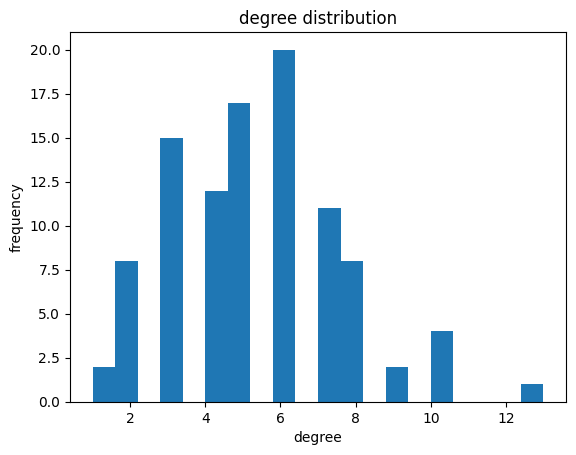

In [ ]:
node_degrees = dict(gh.degree())
plt.Figure(figsize=(4, 4))
plt.hist(node_degrees.values(), bins=20)
plt.xlabel("degree")
plt.ylabel("frequency")
plt.title("degree distribution")
plt.show()

#### Przygotuj dataframe oraz jego opis statystyczny z wykorzystaniem funkcji describe. DataFrame powinien zawierać metryki obliczone dla wygenerowanej sieci losowej, przy czym

In [ ]:
betweenness = nx.betweenness_centrality(gh)
closness = nx.closeness_centrality(gh)
clustering = nx.clustering(gh)
page_rank = nx.pagerank(gh)

if nx.is_connected(gh):
    avg_path = nx.average_shortest_path_length(gh)
    diameter = nx.diameter(gh)
else:
    largest_cc = max(nx.connected_components(gh), key=len)
    subgraph = gh.subgraph(largest_cc)
    avg_path = nx.average_shortest_path_length(subgraph)
    diameter = nx.diameter(subgraph)

num_components = nx.number_connected_components(gh)

In [ ]:
pd.DataFrame(
    {
        "Betweenness": pd.Series(betweenness),
        "Closeness": pd.Series(closness),
        "Clustering_Coeff": pd.Series(clustering),
        "PageRank": pd.Series(page_rank),
        "Avg_Shortest_Path": avg_path,
        "Diameter": diameter,
        "Num_Components": num_components,
    }
).describe()

,Betweenness,Closeness,Clustering_Coeff,PageRank,Avg_Shortest_Path,Diameter,Num_Components
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0
mean,0.019695,0.344551,0.040136,0.010000,2.930101,6.0,1.0
std,0.016443,0.032891,0.062951,0.003565,0.000000,0.0,0.0
min,0.000000,0.248744,0.000000,0.003134,2.930101,6.0,1.0
25%,0.006842,0.321429,0.000000,0.007304,2.930101,6.0,1.0
50%,0.015779,0.348592,0.000000,0.009825,2.930101,6.0,1.0
75%,0.028904,0.364306,0.071429,0.012300,2.930101,6.0,1.0
max,0.087762,0.428571,0.333333,0.021886,2.930101,6.0,1.0


#### Ile jest komponentów (connected components) w grafie,

In [57]:
nx.number_connected_components(gh)

1

#### Zwizualizuj graf w taki sposób, aby rozmiar węzłów odpowiadał mierze PageRank

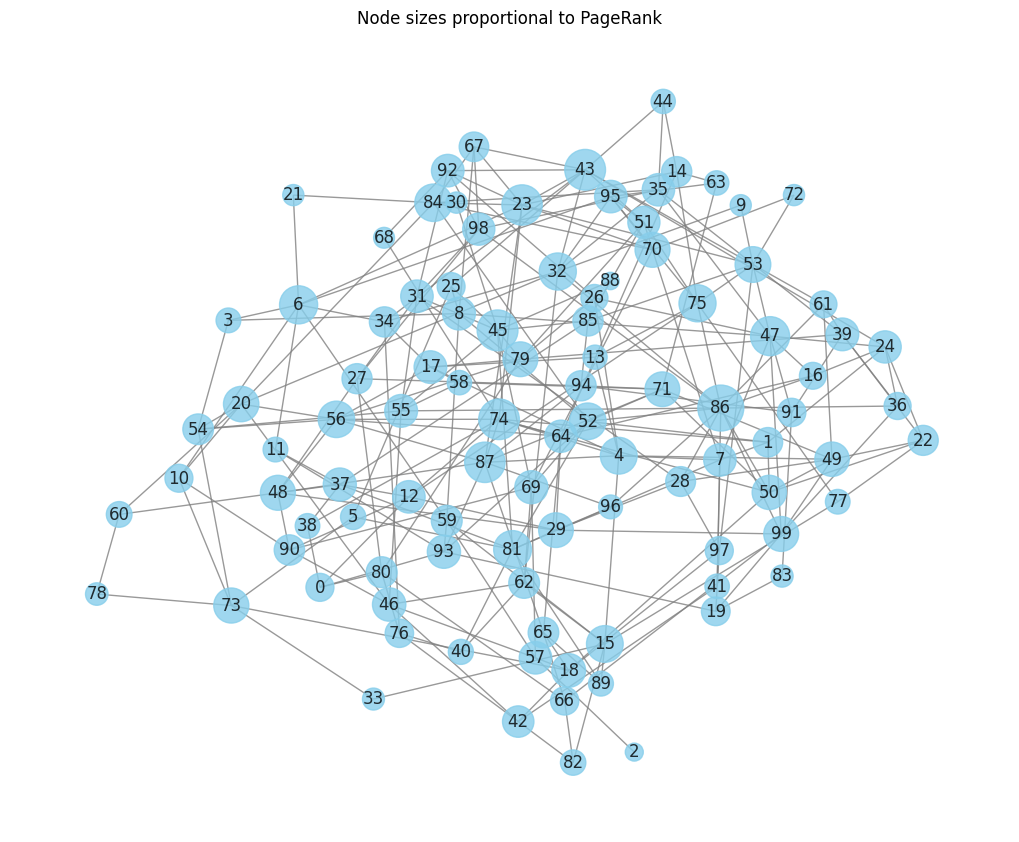

In [ ]:
pagerank = nx.pagerank(gh)


sizes = [v * 50000 for v in pagerank.values()]

plt.figure(figsize=(10, 8))
pos = nx.forceatlas2_layout(gh)

nx.draw(
    gh,
    pos,
    node_size=sizes,
    node_color="skyblue",
    with_labels=True,
    edge_color="gray",
    alpha=0.8,
)

plt.title("Node sizes proportional to PageRank")
plt.show()

___

#### Wygeneruj graf wedle modelu Barabási-Albert z N = 1000 i m0 = m = 3

In [ ]:
N, m = 1000, 3
ba = nx.barabasi_albert_graph(N, m)

#### Zwizualizuj graf layoutem Kamada-Kawai

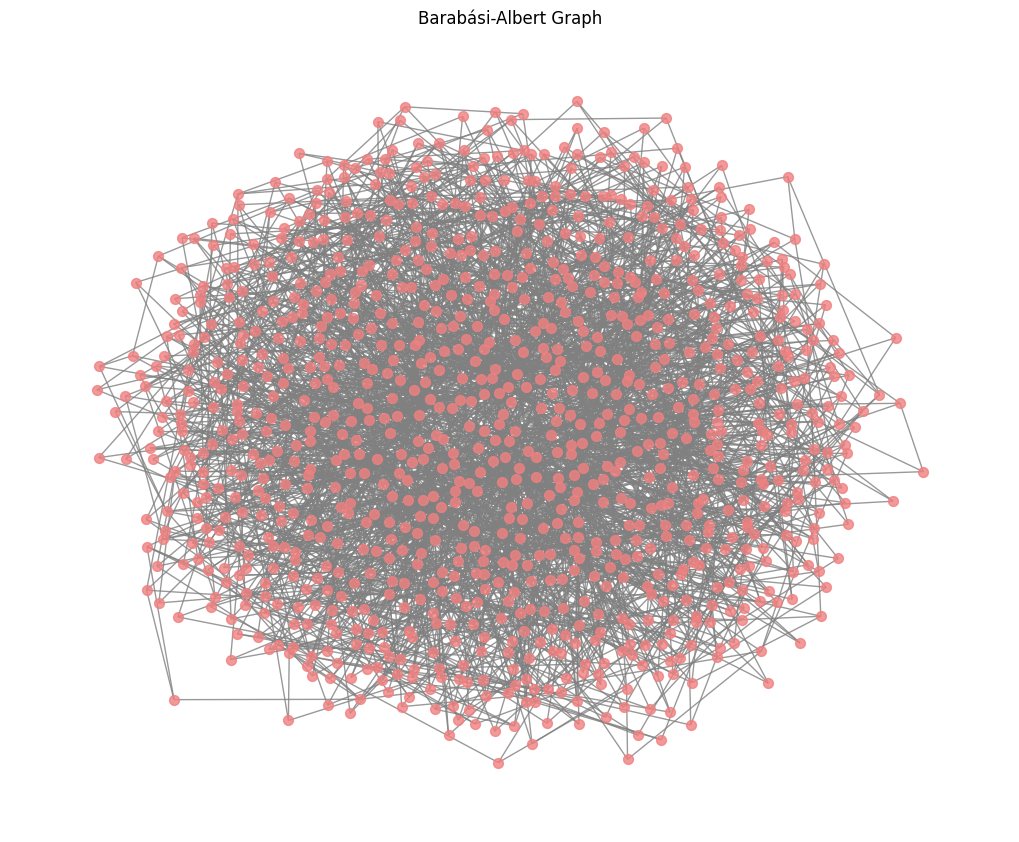

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.kamada_kawai_layout(ba)
nx.draw(
    ba,
    pos,
    node_size=50,
    node_color="lightcoral",
    with_labels=False,
    edge_color="gray",
    alpha=0.8,
)
plt.title("Barabási-Albert Graph")
plt.show()

#### Znajdź najbardziej centralny węzeł według miary pośrednictwa (be-tweenness), jaki ma numer?

In [ ]:
centrality = nx.degree_centrality(ba)

most_central = max(centrality, key=centrality.get)
print(f"most central node: {most_central} with degree: {ba.degree(most_central)}")

most central node: 5 with degree 81


#### Jaka jest średnica grafu?

In [ ]:
diameter = nx.diameter(ba)
print(f"diameter of the graph: {diameter}")

diameter of the graph: 6


### Jakie różnice widzisz pomiędzy grafem Barabási-Albert i Erdős-Rényi.

...

____

In [29]:
g = nx.read_edgelist(
    "ia-radoslaw-email.edges.csv",
    delimiter=",",
    nodetype=int,
    create_using=nx.MultiDiGraph(),
)

In [30]:
f"Number of nodes: {len(g.nodes())}, Number of edges: {len(g.edges())}"

'Number of nodes: 167, Number of edges: 82927'

In [31]:
g.remove_edges_from(nx.selfloop_edges(g))
g = nx.Graph(g)

In [32]:
f"Number of nodes: {len(g.nodes())}, Number of edges: {len(g.edges())}"

'Number of nodes: 167, Number of edges: 3250'

Text(0, 0.5, 'Frequency')

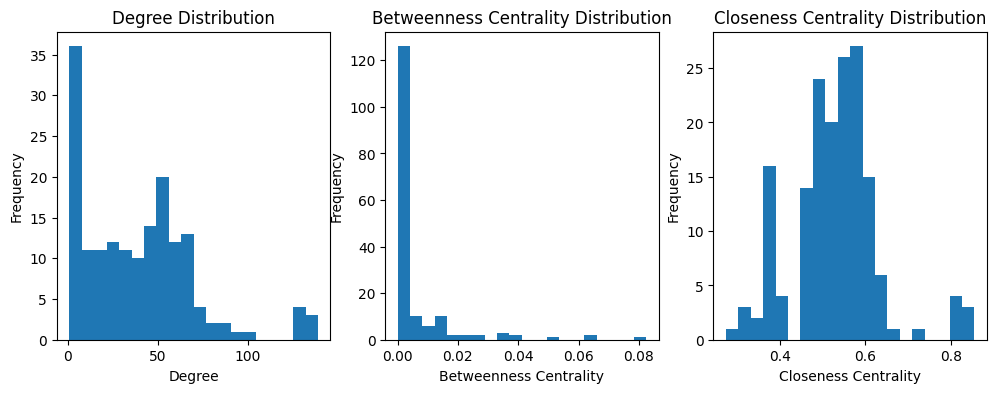

In [40]:
degrees = dict(g.degree())
betweenness = dict(nx.betweenness_centrality(g))
closeness = dict(nx.closeness_centrality(g))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].hist(degrees.values(), bins=20)
ax[0].set_title("Degree Distribution")
ax[0].set_xlabel("Degree")
ax[0].set_ylabel("Frequency")

ax[1].hist(betweenness.values(), bins=20)
ax[1].set_title("Betweenness Centrality Distribution")
ax[1].set_xlabel("Betweenness Centrality")
ax[1].set_ylabel("Frequency")

ax[2].hist(closeness.values(), bins=20)
ax[2].set_title("Closeness Centrality Distribution")
ax[2].set_xlabel("Closeness Centrality")
ax[2].set_ylabel("Frequency")

In [41]:
deg_rank = sorted(degrees, key=degrees.get, reverse=True)
bet_rank = sorted(betweenness, key=betweenness.get, reverse=True)
clo_rank = sorted(closeness, key=closeness.get, reverse=True)

print("Top degree:", deg_rank[:10])
print("Top betweenness:", bet_rank[:10])
print("Top closeness:", clo_rank[:10])

Top degree: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]
Top betweenness: [38, 37, 45, 47, 1, 68, 35, 113, 84, 80]
Top closeness: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]


In [42]:
from scipy.stats import kendalltau

deg_vals = [degrees[n] for n in g.nodes()]
bet_vals = [betweenness[n] for n in g.nodes()]
clo_vals = [closeness[n] for n in g.nodes()]

print("Degree vs Betweenness:", kendalltau(deg_vals, bet_vals))
print("Degree vs Closeness:", kendalltau(deg_vals, clo_vals))
print("Betweenness vs Closeness:", kendalltau(bet_vals, clo_vals))

Degree vs Betweenness: SignificanceResult(statistic=np.float64(0.8042256182614058), pvalue=np.float64(6.874122563216967e-51))
Degree vs Closeness: SignificanceResult(statistic=np.float64(0.950852791382257), pvalue=np.float64(5.182614210404855e-72))
Betweenness vs Closeness: SignificanceResult(statistic=np.float64(0.7839475424697699), pvalue=np.float64(2.1587675953142128e-49))


In [46]:
nx.number_connected_components(g)

1